In [52]:
# Imports and initializaion
import numpy as np
import matplotlib.pyplot as plt
import spe_loader as sl
import scipy as sp
import scipy.constants as sc
import glob
from scipy.stats import norm
import pandas as pd
from scipy.optimize import curve_fit
import sys
sys.path.append('..')
from spefile3 import *


Temp dependence

Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object


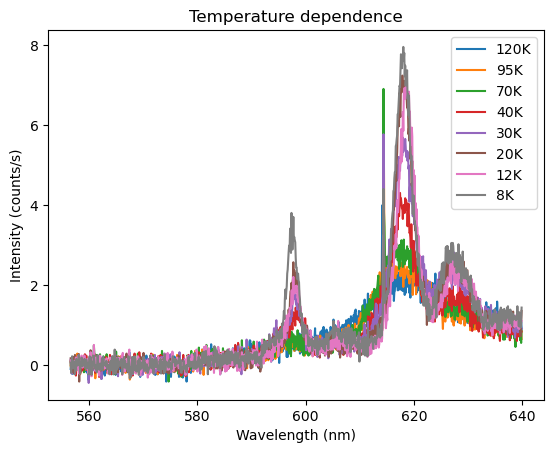

In [101]:
filenames = ["/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_120K 2024 December 05 17_54_06.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_95K 2024 December 05 17_26_32.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_70K 2024 December 05 17_07_54.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_40K 2024 December 05 16_48_31.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_30K 2024 December 05 16_41_23.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_20K 2024 December 05 16_27_30.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/tempdep/482_10uW_60sec_615center_300groove_12K 2024 December 05 16_10_33.spe",
             "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_10uW_60sec_615center_300groove 2024 December 05 15_42_34.spe"]
frameNum = 0
bkgfile = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/bkg_60sec_615center_300groove 2024 December 05 12_36_59.spe"
temps = [120, 95, 70, 40, 30, 20, 12, 8]

for i in range(len(filenames)):
    # if i == 0: 
    #     s = speFile3(filenames[i])
    #     b = speFile3(bkgfile)
    #     s.data = np.array(s.data) - np.array(b.data)
    #     s.data = s.data - np.mean(s.data[0:100])
    # else:
    s = speFile3(filenames[i])
    s.data = np.array(s.data)/s.exposure
    #Select data within the range from the beginning to 640 nm
    mask = (s.wavelengths <= 640)
    x_data = s.wavelengths[mask]
    y_data = s.data[frameNum][0][0][mask]
    plt.plot(x_data, y_data, label = str(temps[i]) + 'K')
    plt.legend()
    plt.ylabel('Intensity (counts/s)')
    plt.title('Temperature dependence')
    plt.xlabel('Wavelength (nm)')

Low T power dependence for biexciton

Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Error - curve_fit failed
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Successfully loaded 1 file(s) in a SpeFile object
Biexciton intensity:  [0, 0.23469768724069592, 2.965595104824073, 1.9635439302229898, 19.85532295363874]
Exciton intensity:  [0.5769455116871194, 1.479661035216101, 7.235363169187088, 6.405734266471293, 14.155122629596898]
Phonon intensity:  [0.16332821695273528, 0.6046971891157438, 2.7099789989584826, 2.658878849762724, 5.98679141003131]


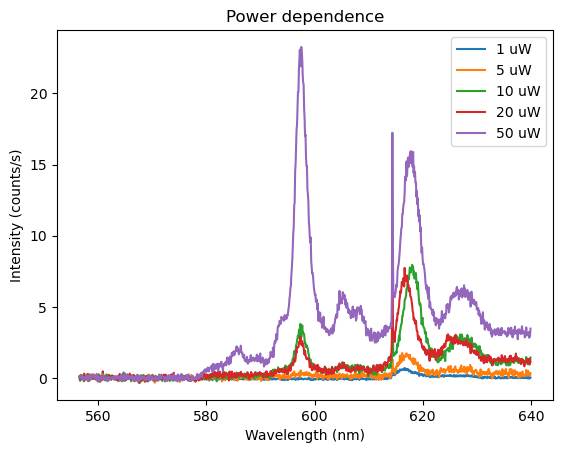

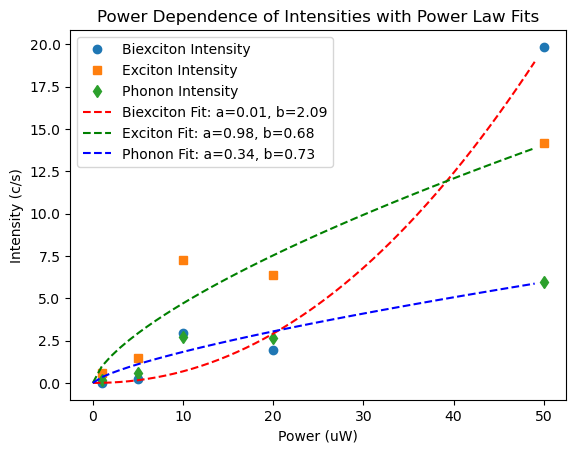

In [96]:
# Power dependence
filenames = ["/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_10uW_60sec_615center_300groove 2024 December 05 15_42_34.spe",
"/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_20uW_60sec_615center_300groove 2024 December 05 15_34_05.spe",
"/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_50uW_60sec_615center_300groove 2024 December 05 15_38_19.spe",
"/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_5uW_60sec_615center_300groove 2024 December 05 15_07_29.spe",
"/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/power/482_1uW_300sec_615center_300groove 2024 December 05 15_21_02.spe"]
frameNum = 0
bkgfile = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/bkg_60sec_615center_300groove 2024 December 05 12_36_59.spe"
powers = [10,20,50,5,1] # in uW
biex_intensity = []
ex_intensity = []
phonon_intensity = []   
# Sort powers and filenames in ascending order by powers
sorted_indices = sorted(range(len(powers)), key=lambda k: powers[k])
powers = [powers[i] for i in sorted_indices]
filenames = [filenames[i] for i in sorted_indices]
for i in range(len(filenames)):
    if i == 0: # 1uW file is 300 sec long and not bkg subtracted
        s = speFile3(filenames[i])
        b = speFile3(bkgfile)
        s.data = np.array(s.data) - np.array(b.data)
        s.data = s.data - np.mean(s.data[0:100])
    else:
        s = speFile3(filenames[i])
    s.data = np.array(s.data)/s.exposure
    # Select data within the range from the beginning to 640 nm
    mask = (s.wavelengths <= 640)
    x_data = s.wavelengths[mask]
    y_data = s.data[frameNum][0][0][mask]
    plt.plot(x_data, y_data, label = str(powers[i]) + ' uW')
    plt.legend()
    plt.ylabel('Intensity (counts/s)')
    plt.title('Power dependence')
    plt.xlabel('Wavelength (nm)')

    # fit 595 peak
    # Select data within the range 590 to 600 nm
    mask_gaussian = (s.wavelengths >= 590) & (s.wavelengths <= 605)
    x_data_gaussian = s.wavelengths[mask_gaussian]
    y_data_gaussian = s.data[frameNum][0][0][mask_gaussian]

    # Define Gaussian function
    def gaussian(x, mu, sigma, a):
        return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

    # Fit the data to the Gaussian function
    try:
        popt_gaussian, _ = curve_fit(gaussian, x_data_gaussian, y_data_gaussian, p0=[595, 1, np.max(y_data_gaussian)])
        biex_intensity.append(popt_gaussian[2])
    except RuntimeError:
        print('Error - curve_fit failed')
        popt_gaussian = [0, 0, 0]
        biex_intensity.append(0)


    # fit 615 peak
    # Select data within the range 590 to 600 nm
    mask_gaussian = (s.wavelengths >= 610) & (s.wavelengths <= 622)
    x_data_gaussian = s.wavelengths[mask_gaussian]
    y_data_gaussian = s.data[frameNum][0][0][mask_gaussian]
    try:
        popt_gaussian, _ = curve_fit(gaussian, x_data_gaussian, y_data_gaussian, p0=[617, 1, np.max(y_data_gaussian)])
        ex_intensity.append(popt_gaussian[2])
    except RuntimeError:
        print('Error - curve_fit failed')
        ex_intensity.append(0)


    # fit 625 peak phonon sideband peak
    # Select data within the range 590 to 600 nm
    mask_gaussian = (s.wavelengths >= 622) & (s.wavelengths <= 632)
    x_data_gaussian = s.wavelengths[mask_gaussian]
    y_data_gaussian = s.data[frameNum][0][0][mask_gaussian]
    try:
        popt_gaussian, _ = curve_fit(gaussian, x_data_gaussian, y_data_gaussian, p0=[627, 1, np.max(y_data_gaussian)])
        #plt.plot(x_data_gaussian, gaussian(x_data_gaussian, *popt_gaussian))
        phonon_intensity.append(popt_gaussian[2])
        #print(popt_gaussian)
    except RuntimeError:
        print('Error - curve_fit failed')
        phonon_intensity.append(0)

print('Biexciton intensity: ', biex_intensity) 
print('Exciton intensity: ', ex_intensity)
print('Phonon intensity: ', phonon_intensity)


plt.figure()
plt.plot(powers, biex_intensity, 'o', label='Biexciton Intensity')
plt.plot(powers, ex_intensity, 's', label='Exciton Intensity')
plt.plot(powers, phonon_intensity, 'd', label='Phonon Intensity')
plt.xlabel('Power (uW)')
plt.ylabel('Intensity (c/s)')
plt.title('Power Dependence of Intensities')
plt.legend()
# Define power law function
def power_law(x, a, b):
    return a * np.power(x, b)
powers_fit = np.arange(0, 50, 1)
# Fit and plot power law for biexciton intensity
popt_biex, _ = curve_fit(power_law, powers, biex_intensity)
plt.plot(powers_fit, power_law(powers_fit, *popt_biex), 'r--', label=f'Biexciton Fit: a={popt_biex[0]:.2f}, b={popt_biex[1]:.2f}')

# Fit and plot power law for exciton intensity
popt_ex, _ = curve_fit(power_law, powers, ex_intensity)
plt.plot(powers_fit, power_law(powers_fit, *popt_ex), 'g--', label=f'Exciton Fit: a={popt_ex[0]:.2f}, b={popt_ex[1]:.2f}')

# Fit and plot power law for phonon intensity
popt_phonon, _ = curve_fit(power_law, powers, phonon_intensity)
plt.plot(powers_fit, power_law(powers_fit, *popt_phonon), 'b--', label=f'Phonon Fit: a={popt_phonon[0]:.2f}, b={popt_phonon[1]:.2f}')

plt.xlabel('Power (uW)')
plt.ylabel('Intensity (c/s)')
plt.title('Power Dependence of Intensities with Power Law Fits')
plt.legend()
plt.show()


Low T cavity data

Successfully loaded 1 file(s) in a SpeFile object


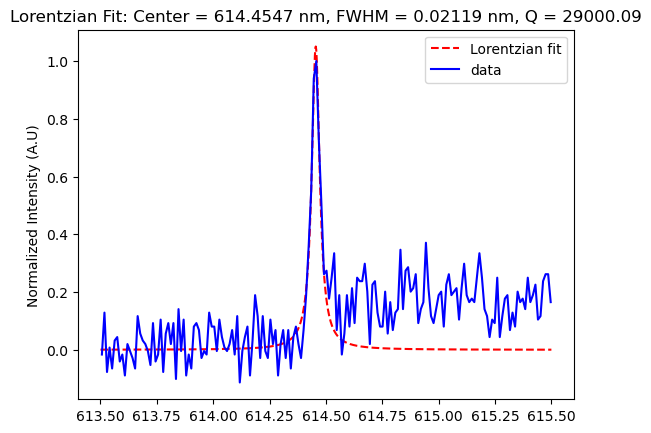

In [ ]:
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/482_10uW_100sec_615center_1800groove 2024 December 05 14_53_24.spe"
s = speFile3(filename)
frameNum = 0
#s.quickPlot(frame = frameNum, ylim= None)
# Select data within the range 613 to 615 nm
mask = (s.wavelengths >= 613.5) & (s.wavelengths <= 614.5)
x_data = s.wavelengths[mask]
y_data = s.data[frameNum][0][0][mask]
# Take average of first 20 points
average_first_20 = np.mean(y_data[:20])

# Subtract the average from y_data
y_data_bkg_subtracted = y_data - average_first_20
# Normalize y_data_bkg_subtracted
y_data_normalized = (y_data_bkg_subtracted) / (np.max(y_data_bkg_subtracted))

# Fit the data to the Lorentzian function
popt, _ = curve_fit(lorentzian, x_data, y_data_normalized, p0=[614, 0.02, 1])

# Plot the fitted curve
x_fit = np.linspace(613.5, 615.5, 1000)
y_fit = lorentzian(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', label='Lorentzian fit')

mask2 = (s.wavelengths >= 613.5) & (s.wavelengths <= 615.5)
x_data = s.wavelengths[mask2]
y_data = s.data[frameNum][0][0][mask2]
y_data_bkg_subtracted = y_data - average_first_20
y_data_normalized = (y_data_bkg_subtracted) / (np.max(y_data_bkg_subtracted))
plt.plot(x_data, y_data_normalized, 'b-', label='data')
plt.ylabel('Normalized Intensity (A.U)')
plt.legend()
plt.title(f"Lorentzian Fit: Center = {popt[0]:.4f} nm, FWHM = {popt[1]:.5f} nm, Q = {popt[0]/popt[1]:.2f}")
plt.show()

Successfully loaded 1 file(s) in a SpeFile object


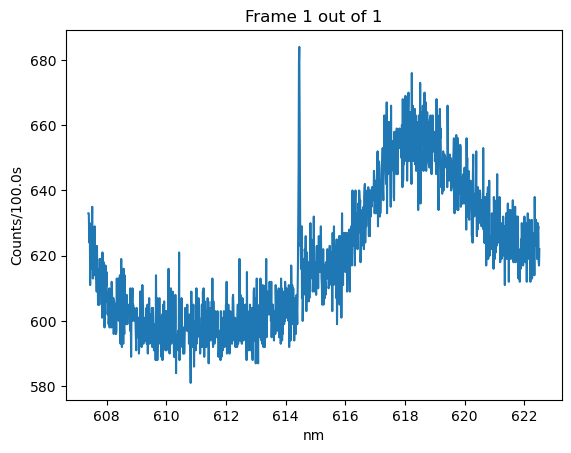

In [48]:
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/482_10uW_100sec_615center_1800groove 2024 December 05 14_53_24.spe"
s = speFile3(filename)
frameNum = 0
s.quickPlot(frame = frameNum, ylim= None)

Low T spectra

Successfully loaded 1 file(s) in a SpeFile object


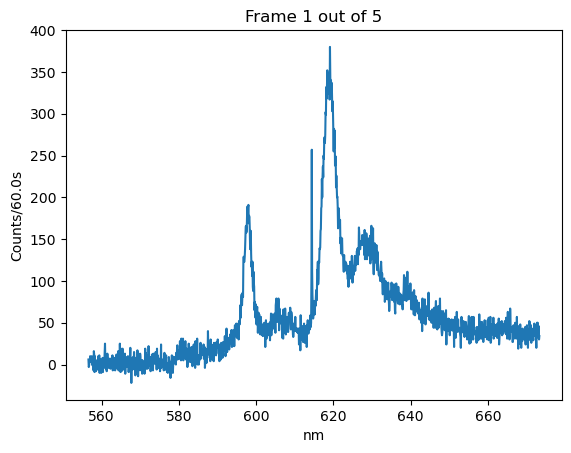

In [36]:
filename = "/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_05/cold482/482_10uW_60sec_615center_300groove 2024 December 05 12_41_00.spe"
s = speFile3(filename)
frameNum = 0
s.quickPlot(frame = frameNum, ylim= None)

Transmisson room T

Successfully loaded 1 file(s) in a SpeFile object


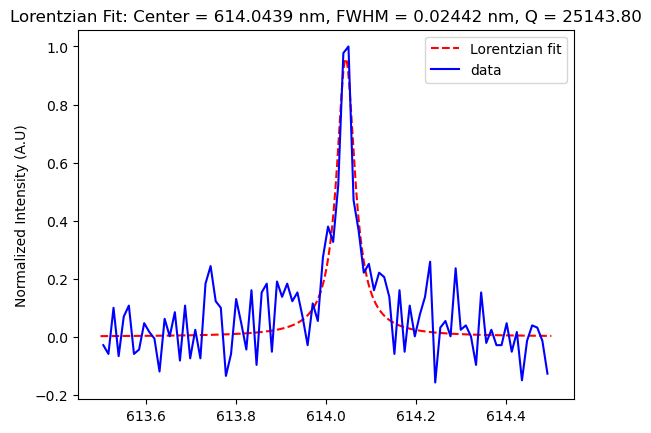

In [22]:
filename = '/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_04/482/transmission_Grating/482_10uW_300sec_615center_1800groove 2024 December 04 17_56_39.spe'
s = speFile3(filename)
frameNum = 0
# s.quickPlot(frame = frameNum, ylim= None)
# plt.xlim(613,615)
# plt.ylim(0, 1000)
# Define Lorentzian function
def lorentzian(x, x0, gamma, a):
    return a/np.pi * (gamma / ((x - x0)**2 + (gamma)**2))

# Select data within the range 613 to 615 nm
mask = (s.wavelengths >= 613.5) & (s.wavelengths <= 614.5)
x_data = s.wavelengths[mask]
y_data = s.data[frameNum][0][0][mask]
# Take average of first 20 points
average_first_20 = np.mean(y_data[:20])

# Subtract the average from y_data
y_data_bkg_subtracted = y_data - average_first_20
# Normalize y_data_bkg_subtracted
y_data_normalized = (y_data_bkg_subtracted) / (np.max(y_data_bkg_subtracted))

# Fit the data to the Lorentzian function
popt, _ = curve_fit(lorentzian, x_data, y_data_normalized, p0=[614, 0.01, 1])

# Plot the fitted curve
x_fit = np.linspace(613.5, 614.5, 1000)
y_fit = lorentzian(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', label='Lorentzian fit')
plt.plot(x_data, y_data_normalized, 'b-', label='data')
plt.ylabel('Normalized Intensity (A.U)')
plt.legend()
plt.title(f"Lorentzian Fit: Center = {popt[0]:.4f} nm, FWHM = {popt[1]:.5f} nm, Q = {popt[0]/popt[1]:.2f}")
plt.show()

Grating analysis at 1800 for cavity

Successfully loaded 1 file(s) in a SpeFile object


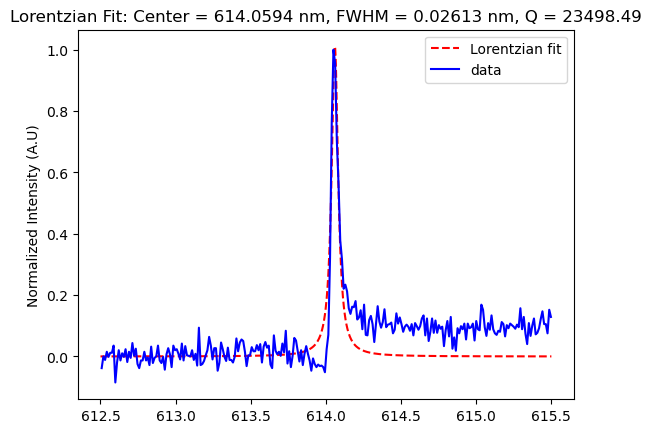

In [34]:
filename = '/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_04/482/slit_closed/482_10uW_300sec_615center_1800groove 2024 December 04 16_39_51.spe'
s = speFile3(filename)
frameNum = 0
#s.quickPlot(frame = frameNum, ylim= None)
def lorentzian(x, x0, gamma, a):
    return a/np.pi * (gamma / ((x - x0)**2 + (gamma)**2))

# Select data within the range 613 to 615 nm
mask = (s.wavelengths >= 612.5) & (s.wavelengths <= 615.5)
x_data = s.wavelengths[mask]
y_data = s.data[frameNum][0][0][mask]
# Take average of first 20 points
average_first_20 = np.mean(y_data[:20])

# Subtract the average from y_data
y_data_bkg_subtracted = y_data - average_first_20
# Normalize y_data_bkg_subtracted
y_data_normalized = (y_data_bkg_subtracted) / (np.max(y_data_bkg_subtracted))

# Fit the data to the Lorentzian function
popt, _ = curve_fit(lorentzian, x_data, y_data_normalized, p0=[614, 0.01, 1])

# Plot the fitted curve
x_fit = np.linspace(612.5, 615.5, 1000)
y_fit = lorentzian(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', label='Lorentzian fit')
plt.plot(x_data, y_data_normalized, 'b-', label='data')
plt.ylabel('Normalized Intensity (A.U)')
plt.legend()
plt.title(f"Lorentzian Fit: Center = {popt[0]:.4f} nm, FWHM = {popt[1]:.5f} nm, Q = {popt[0]/popt[1]:.2f}")
plt.show()


Broad 300g/mm grating spectra

Successfully loaded 1 file(s) in a SpeFile object


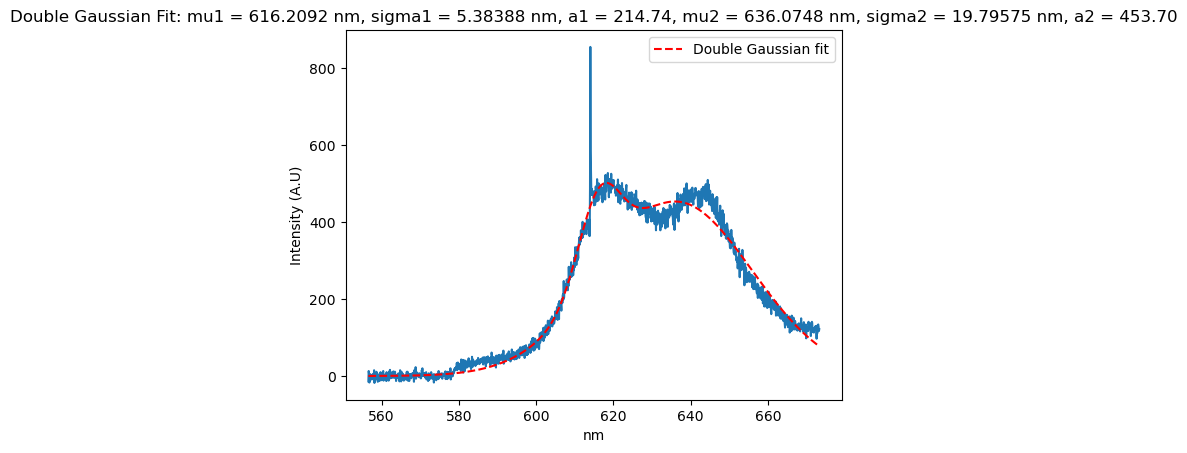

In [31]:
filename = '/Users/tommtommbom/Desktop/qdrepos/CdSeSpecData/2024/2024_12_04/482/slit_closed/482_10uW_60sec_615center 2024 December 04 16_10_06.spe'
s = speFile3(filename)
frameNum = 0
s.quickPlot(frame = frameNum, ylim= None)
# Define a function for the sum of two Gaussians
x_data = s.wavelengths
y_data = s.data[frameNum][0][0]
def double_gaussian(x, mu1, sigma1, a1, mu2, sigma2, a2):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2))

# Fit the data to the double Gaussian function
popt, _ = curve_fit(double_gaussian, x_data, y_data, p0=[620, 20, 500, 650, 20, 500])

# Plot the fitted curve
y_fit = double_gaussian(s.wavelengths, *popt)
plt.plot(s.wavelengths, y_fit, 'r--', label='Double Gaussian fit')
#plt.plot(x_data, y_data, 'b-', label='data')
plt.ylabel('Intensity (A.U)')
plt.legend()
plt.title(f"Double Gaussian Fit: mu1 = {popt[0]:.4f} nm, sigma1 = {popt[1]:.5f} nm, a1 = {popt[2]:.2f}, mu2 = {popt[3]:.4f} nm, sigma2 = {popt[4]:.5f} nm, a2 = {popt[5]:.2f}")
plt.show()